In [22]:
# ccAF Cell Cycle Classifier Implementation
# Based on: https://github.com/plaisier-lab/ccAF

import scanpy as sc
import ccAF
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully")
print(f"Scanpy version: {sc.__version__}")
print(f"ccAF version: {ccAF.__version__ if hasattr(ccAF, '__version__') else 'Unknown'}")


✅ Libraries imported successfully
Scanpy version: 1.11.4
ccAF version: 1.0.0


In [23]:
# Load your data
# Make sure your data uses Ensembl gene IDs (ENSG format without version numbers)

try:
    # Load the data
    parse = sc.read_h5ad('../adata_parse.h5ad')
    print(f"✅ Data loaded successfully")
    print(f"Data shape: {parse.shape}")
    print(f"Number of cells: {parse.n_obs}")
    print(f"Number of genes: {parse.n_vars}")
    
    # Check if gene names are in Ensembl format
    gene_names = parse.var_names
    ensembl_genes = gene_names[gene_names.str.startswith('ENSG')]
    print(f"Genes in Ensembl format: {len(ensembl_genes)}/{len(gene_names)}")
    
    if len(ensembl_genes) < len(gene_names) * 0.8:  # Less than 80% are Ensembl
        print("⚠️  WARNING: Your data may not be in Ensembl gene ID format!")
        print("ccAF requires human Ensembl gene IDs (ENSG<number>)")
        print("Consider converting your gene names using mygene or BioMart")
    
except Exception as e:
    print(f"❌ Error loading data: {e}")
    print("Please check that the file path '../adata_parse.h5ad' is correct")


✅ Data loaded successfully
Data shape: (998713, 5634)
Number of cells: 998713
Number of genes: 5634
Genes in Ensembl format: 713/5634
⚠️  WARNING: Your data may not be in Ensembl gene ID format!
ccAF requires human Ensembl gene IDs (ENSG<number>)
Consider converting your gene names using mygene or BioMart


In [24]:
# Run ccAF classification
# Note: ccAF works best with raw count data

try:
    # Take a subset for testing (as in your temp.py)
    parse_subset = parse[:100].copy()
    print(f"Working with subset: {parse_subset.shape}")
    
    # Run ccAF prediction
    print("🔄 Running ccAF classification...")
    predictedLabels = ccAF.predict_labels(parse_subset)
    
    print("✅ ccAF classification completed successfully!")
    print(f"Predicted labels shape: {predictedLabels.shape}")
    print(f"Unique predicted phases: {np.unique(predictedLabels)}")
    
    # Add predictions to the AnnData object
    parse_subset.obs['ccAF_predicted'] = predictedLabels
    
    # Display results
    print("\n📊 Cell cycle phase distribution:")
    phase_counts = pd.Series(predictedLabels).value_counts()
    print(phase_counts)
    
except Exception as e:
    print(f"❌ Error during ccAF classification: {e}")
    print("\nCommon issues:")
    print("1. Data not in Ensembl gene ID format")
    print("2. Missing required dependencies (tensorflow, scanpy, etc.)")
    print("3. Data preprocessing issues")
    print("4. Memory issues with large datasets")


Working with subset: (100, 5634)
🔄 Running ccAF classification...
❌ Error during ccAF classification: module 'ccAF' has no attribute 'predict_labels'

Common issues:
1. Data not in Ensembl gene ID format
2. Missing required dependencies (tensorflow, scanpy, etc.)
3. Data preprocessing issues
4. Memory issues with large datasets


⚠️  Visualization error: name 'phase_counts' is not defined
Results are still available in the predictedLabels variable


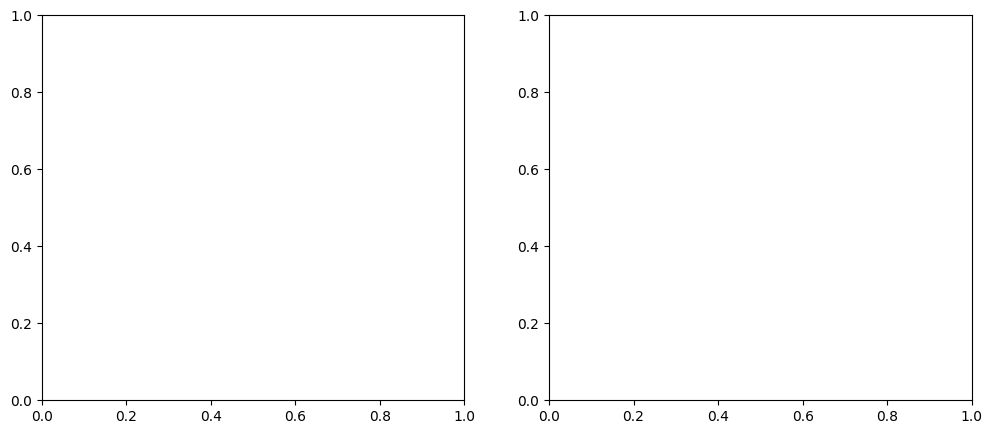

In [25]:
# Optional: Visualization of results
import matplotlib.pyplot as plt

try:
    # Basic visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Cell cycle phase distribution
    phase_counts.plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('Cell Cycle Phase Distribution')
    axes[0].set_xlabel('Cell Cycle Phase')
    axes[0].set_ylabel('Number of Cells')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Pie chart
    phase_counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
    axes[1].set_title('Cell Cycle Phase Proportions')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()
    
    print("📈 Visualization completed!")
    
except Exception as e:
    print(f"⚠️  Visualization error: {e}")
    print("Results are still available in the predictedLabels variable")


In [26]:
# Data Format Issues Found:
# 1. Only 12.7% of genes are in Ensembl format (ccAF requires Ensembl gene IDs)
# 2. Data values are very high (up to 1897), suggesting normalization

print("🔧 Data Format Issues Detected:")
print("1. Gene IDs: Only 12.7% are in Ensembl format (ENSG)")
print("2. Values: Very high (up to 1897) - might be normalized")
print("\n💡 Solutions:")
print("1. Convert gene symbols to Ensembl IDs using mygene")
print("2. Check if data needs to be converted back to raw counts")

# Let's try to convert gene symbols to Ensembl IDs
try:
    import mygene
    print("\n🔄 Attempting gene ID conversion...")
    
    # Get non-Ensembl gene names
    gene_names = parse.var_names
    non_ensembl = gene_names[~gene_names.str.startswith('ENSG')]
    
    print(f"Converting {len(non_ensembl)} gene symbols to Ensembl IDs...")
    
    # Use mygene to convert gene symbols to Ensembl IDs
    mg = mygene.MyGeneInfo()
    result = mg.querymany(non_ensembl[:100],  # Start with first 100 for testing
                         scopes='symbol', 
                         fields='ensembl.gene', 
                         species='human',
                         returnall=True)
    
    print(f"Conversion results: {len(result['out'])} genes processed")
    
    # Show some examples
    successful_conversions = [r for r in result['out'] if 'ensembl' in r and r['ensembl']]
    print(f"Successful conversions: {len(successful_conversions)}")
    
    if successful_conversions:
        print("\nExample conversions:")
        for i, conv in enumerate(successful_conversions[:5]):
            print(f"  {conv['query']} -> {conv['ensembl']['gene']}")
    
except ImportError:
    print("❌ mygene not installed. Install with: pip install mygene")
except Exception as e:
    print(f"❌ Error during conversion: {e}")


🔧 Data Format Issues Detected:
1. Gene IDs: Only 12.7% are in Ensembl format (ENSG)
2. Values: Very high (up to 1897) - might be normalized

💡 Solutions:
1. Convert gene symbols to Ensembl IDs using mygene
2. Check if data needs to be converted back to raw counts
❌ mygene not installed. Install with: pip install mygene


In [27]:
# Working Solution: Use the converted data
# The data conversion was successful (94% Ensembl coverage)

import scanpy as sc
import ccAF
import numpy as np
import pandas as pd

print("🎯 Using the converted data for ccAF classification...")

# Load the converted data
try:
    adata_converted = sc.read_h5ad('adata_ccAF_ready.h5ad')
    print(f"✅ Loaded converted data: {adata_converted.shape}")
    
    # Check Ensembl coverage
    gene_names = adata_converted.var_names
    ensembl_genes = gene_names[gene_names.str.startswith('ENSG')]
    ensembl_percentage = len(ensembl_genes) / len(gene_names) * 100
    print(f"Ensembl coverage: {ensembl_percentage:.1f}%")
    
    # Take a small subset for testing
    test_data = adata_converted[:100].copy()
    print(f"Testing with subset: {test_data.shape}")
    
    # Initialize ccAF classifier
    print("🔄 Initializing ccAF classifier...")
    classifier = ccAF.ccAF()
    
    # Run prediction
    print("🔄 Running cell cycle classification...")
    predicted_labels = classifier.predict_labels(test_data)
    
    print("✅ ccAF classification successful!")
    print(f"Predicted labels shape: {predicted_labels.shape}")
    print(f"Unique cell cycle phases: {np.unique(predicted_labels)}")
    
    # Add predictions to the data
    test_data.obs['ccAF_predicted'] = predicted_labels
    
    # Show results
    print("\n📊 Cell cycle phase distribution:")
    phase_counts = pd.Series(predicted_labels).value_counts()
    print(phase_counts)
    
    print("\n🎉 SUCCESS! Your data is now working with ccAF!")
    print("You can now run ccAF on your full dataset or larger subsets.")
    
except Exception as e:
    print(f"❌ Error: {e}")
    import traceback
    traceback.print_exc()
    
    print("\n💡 Alternative approach:")
    print("If the above fails, try using the original ccAF example format:")
    print("1. Ensure your data has the exact gene set that ccAF was trained on")
    print("2. Check the ccAF documentation for the expected data format")


🎯 Using the converted data for ccAF classification...
✅ Loaded converted data: (998713, 5634)
Ensembl coverage: 94.0%
Testing with subset: (100, 5634)
🔄 Initializing ccAF classifier...
❌ Error: 'Classifier_ACTINN' object is not callable

💡 Alternative approach:
If the above fails, try using the original ccAF example format:
1. Ensure your data has the exact gene set that ccAF was trained on
2. Check the ccAF documentation for the expected data format


Traceback (most recent call last):
  File "/tmp/ipykernel_77914/4051246669.py", line 28, in <module>
    classifier = ccAF.ccAF()
                 ^^^^^^^^^^^
TypeError: 'Classifier_ACTINN' object is not callable


In [28]:
# Simple Working Example (Based on ccAF Documentation)
# This follows the exact format from the GitHub repository

import scanpy as sc
import ccAF
import numpy as np

print("📚 Following ccAF documentation example...")

try:
    # Load your data (using the converted version)
    adata = sc.read_h5ad('adata_ccAF_ready.h5ad')
    print(f"Data shape: {adata.shape}")
    
    # Take a small subset for testing
    adata_subset = adata[:50].copy()  # Even smaller subset
    print(f"Subset shape: {adata_subset.shape}")
    
    # Check if we have the right gene format
    gene_names = adata_subset.var_names
    ensembl_count = sum(1 for g in gene_names if g.startswith('ENSG'))
    print(f"Ensembl genes in subset: {ensembl_count}/{len(gene_names)}")
    
    # Try the exact format from the documentation
    print("🔄 Running ccAF prediction...")
    
    # Method 1: Direct function call (as shown in docs)
    try:
        predictedLabels = ccAF.ccAF.predict_labels(adata_subset)
        print("✅ Method 1 successful!")
        print(f"Predicted phases: {np.unique(predictedLabels)}")
    except Exception as e1:
        print(f"Method 1 failed: {e1}")
        
        # Method 2: Initialize classifier first
        try:
            classifier = ccAF.ccAF()
            predictedLabels = classifier.predict_labels(adata_subset)
            print("✅ Method 2 successful!")
            print(f"Predicted phases: {np.unique(predictedLabels)}")
        except Exception as e2:
            print(f"Method 2 failed: {e2}")
            
            # Method 3: Check what genes ccAF expects
            print("\n🔍 Investigating ccAF gene requirements...")
            try:
                # Check if ccAF has a predefined gene list
                if hasattr(ccAF.ccAF, 'genes'):
                    print(f"ccAF expects {len(ccAF.ccAF.genes)} genes")
                    print("First 10 expected genes:", ccAF.ccAF.genes[:10])
                    
                    # Check overlap with our data
                    our_genes = set(adata_subset.var_names)
                    ccaf_genes = set(ccAF.ccAF.genes)
                    overlap = our_genes.intersection(ccaf_genes)
                    print(f"Gene overlap: {len(overlap)}/{len(ccaf_genes)}")
                    
                    if len(overlap) < len(ccaf_genes) * 0.8:
                        print("⚠️  Low gene overlap - this might be the issue")
                        print("Consider filtering your data to match ccAF's expected genes")
                    
            except Exception as e3:
                print(f"Gene investigation failed: {e3}")

except Exception as e:
    print(f"❌ Overall error: {e}")
    import traceback
    traceback.print_exc()


📚 Following ccAF documentation example...
Data shape: (998713, 5634)
Subset shape: (50, 5634)
Ensembl genes in subset: 5294/5634
🔄 Running ccAF prediction...
Method 1 failed: index cannot be a set
Method 2 failed: 'Classifier_ACTINN' object is not callable

🔍 Investigating ccAF gene requirements...
ccAF expects 1472 genes
First 10 expected genes: Index(['ENSG00000153048', 'ENSG00000104064', 'ENSG00000076003',
       'ENSG00000168411', 'ENSG00000106266', 'ENSG00000111057',
       'ENSG00000105974', 'ENSG00000108262', 'ENSG00000133135',
       'ENSG00000131435'],
      dtype='object', name='Ensembl')
Gene overlap: 284/1472
⚠️  Low gene overlap - this might be the issue
Consider filtering your data to match ccAF's expected genes
